# [Title of the report]


[It is ideal to include a table of contents here to organise content with the right level of heading and sub-headings; makes it much easier to read for your audience. Use the right level of headings (Heading 1, Heading 2 etc.) to preserve hierarchy
]

Impt note: The template only provides sample blocks to ensure you cover the basic requirements of this assignment; you are free to adapt it to your need as required.

## Introduction

[Provide a short paragraph providing background to your analysis, explaining your aims and context. Include specific questions of inquiry, if any]

## Data Ingestion

In [ ]:
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import matplotlib.pyplot as plt
import seaborn as sns
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

In [1]:
import os
from pathlib import Path
import pandas as pd
import pdfplumber
from tqdm import tqdm
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import seaborn as sns

In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
import json
import numpy as np
import pandas as pd
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from IPython.display import HTML, display

In [2]:
# Define fixed input and output paths (using the corrected path structure)
RAW_DATA_PATH = Path("/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/raw")
PROCESSED_DATA_PATH = Path("/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed")

In [3]:
# Ensure output directory exists
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

def extract_pdf_text(filepath):
    """
    Extracts plain text from a PDF file using pdfplumber.
    """
    full_text = []
    try:
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text.append(text)
        return "\n".join(full_text)
    except Exception as e:
        print(f"Error reading {filepath.name}: {e}")
        return None

# Locate all PDF files
pdf_files = list(RAW_DATA_PATH.glob("*.[pP][dD][fF]"))
print(f"Found {len(pdf_files)} PDF files in raw directory.")

# Process files with progress bar
records = []
for pdf_path in tqdm(pdf_files, desc="Extracting PDF text"):
    content = extract_pdf_text(pdf_path)
    if content:
        records.append({
            "archivo": pdf_path.name,
            "tamano_bytes": pdf_path.stat().st_size,
            "texto_raw": content
        })

Found 143 PDF files in raw directory.


Extracting PDF text: 100%|██████████| 143/143 [02:08<00:00,  1.11it/s]


In [4]:
# Create DataFrame
df = pd.DataFrame(records)
print(f"\nSuccessfully extracted text from {len(df)} PDFs.")

# Save raw extracted text to CSV
raw_csv_path = PROCESSED_DATA_PATH / "submissions_raw.csv"
df.to_csv(raw_csv_path, index=False)
print(f"Raw data saved to: {raw_csv_path}")


Successfully extracted text from 143 PDFs.
Raw data saved to: /Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_raw.csv


[Describe your input data set, and provide a high-level explanation of the steps in your code]

In [ ]:
#Add code to ingest data


## Exploratory data analysis

[Add details]



Computing extended raw text metrics...

=== RAW CORPUS OVERALL SUMMARY ===
Total Documents: 143
Total Raw Words (Tokens): 535,709
Total Characters: 3,809,735
Average Words per Document: 3746.22 (Std: 5645.99)
Average Lexical Diversity (Raw TTR): 0.3697

=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===
                               mean           std        min           50%  \
word_count              3746.216783   5645.991148  11.000000   2170.000000   
char_count             26641.503497  38888.869984  71.000000  16048.000000   
line_count               381.909091    552.485433   2.000000    232.000000   
unique_word_count       1074.727273    979.390204  11.000000    842.000000   
avg_word_length            7.117404      0.439699   6.201940      7.106764   
lexical_diversity_ttr      0.369680      0.118205   0.037037      0.367595   
digit_ratio                0.052416      0.035578   0.004545      0.042613   
uppercase_ratio            0.017543      0.014997   0.000000      0.

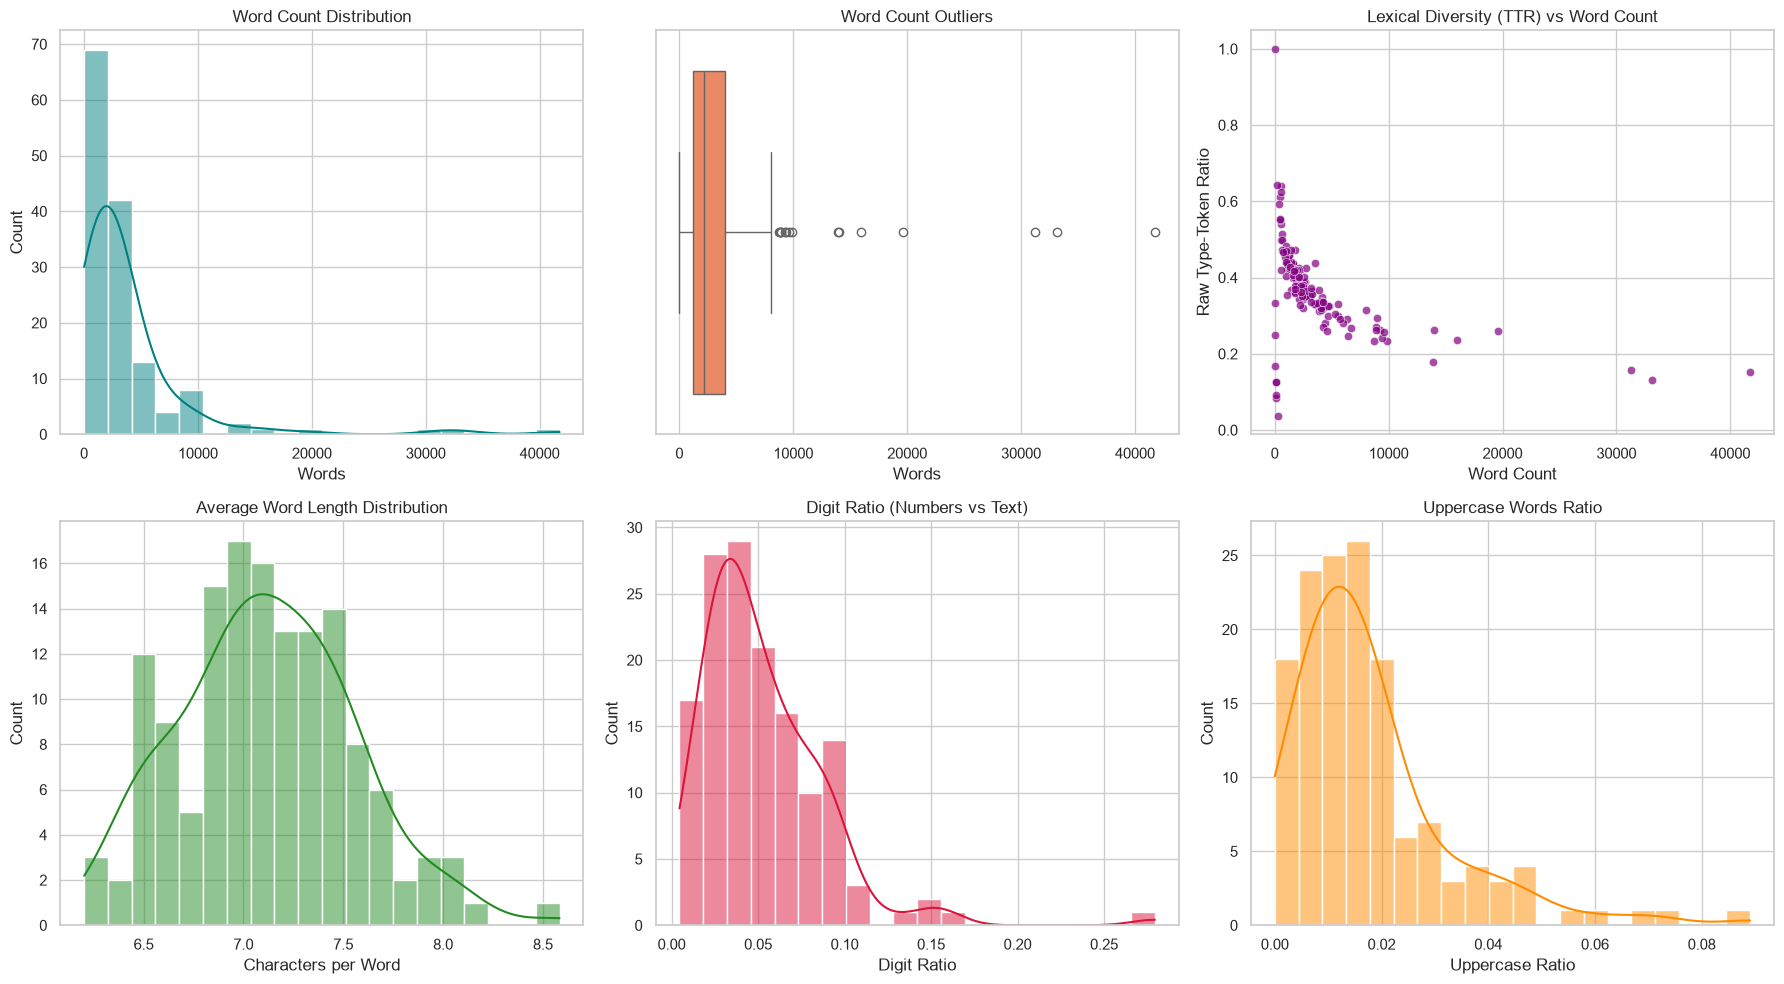

In [6]:
#Code block with appropriate comments for documentation

# --- 1. EXTENDED METRICS COMPUTATION (RAW TEXT) ---
print("Computing extended raw text metrics...")

# Document Length Metrics
df['char_count'] = df['texto_raw'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['word_count'] = df['texto_raw'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
df['line_count'] = df['texto_raw'].apply(lambda x: len(str(x).splitlines()) if pd.notna(x) else 0)

# Lexical & Character Metrics
df['unique_word_count'] = df['texto_raw'].apply(lambda x: len(set(str(x).lower().split())) if pd.notna(x) else 0)
df['avg_word_length'] = df.apply(lambda row: row['char_count'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1)

# Lexical Diversity Metric (Raw Type-Token Ratio)
df['lexical_diversity_ttr'] = df.apply(lambda row: row['unique_word_count'] / row['word_count'] if row['word_count'] > 0 else 0, axis=1)

# Structural & Noise Indicators (Raw text patterns)
df['uppercase_word_count'] = df['texto_raw'].apply(lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 1]) if pd.notna(x) else 0)
df['digit_count'] = df['texto_raw'].apply(lambda x: len(re.findall(r'\d+', str(x))) if pd.notna(x) else 0)
df['punctuation_count'] = df['texto_raw'].apply(lambda x: len(re.findall(r'[^\w\s]', str(x))) if pd.notna(x) else 0)

# Ratio Metrics
df['digit_ratio'] = df['digit_count'] / df['word_count'].replace(0, 1)
df['uppercase_ratio'] = df['uppercase_word_count'] / df['word_count'].replace(0, 1)


# --- 2. STATISTICAL SUMMARY REPORT ---
print("\n=== RAW CORPUS OVERALL SUMMARY ===")
print(f"Total Documents: {len(df):,}")
print(f"Total Raw Words (Tokens): {df['word_count'].sum():,}")
print(f"Total Characters: {df['char_count'].sum():,}")
print(f"Average Words per Document: {df['word_count'].mean():.2f} (Std: {df['word_count'].std():.2f})")
print(f"Average Lexical Diversity (Raw TTR): {df['lexical_diversity_ttr'].mean():.4f}")

print("\n=== ADVANCED RAW TEXT METRICS (DESCRIPTIVE STATS) ===")
metrics_to_show = [
    'word_count', 'char_count', 'line_count', 'unique_word_count', 
    'avg_word_length', 'lexical_diversity_ttr', 'digit_ratio', 'uppercase_ratio'
]
print(df[metrics_to_show].describe().T[['mean', 'std', 'min', '50%', 'max']])


# --- 3. SUSPECT DOCUMENT IDENTIFICATION (QUALITY CHECK) ---
print("\n=== EXTREME DOCUMENTS IDENTIFICATION ===")
# Extremely short documents (possible scanned PDFs or cover pages)
short_docs = df[df['word_count'] < 100][['archivo', 'word_count', 'char_count']]
print(f"Documents with fewer than 100 words: {len(short_docs)}")
if len(short_docs) > 0:
    print(short_docs.head())

# High digit ratio documents (possible tables, financial reports or bad extraction)
high_digit_docs = df[df['digit_ratio'] > 0.1][['archivo', 'word_count', 'digit_ratio']]
print(f"\nDocuments with >10% digits (potential data tables): {len(high_digit_docs)}")
if len(high_digit_docs) > 0:
    print(high_digit_docs.head())


# --- 4. EXTENDED MULTI-PANEL VISUALIZATION ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Chart 1: Word Count Distribution
sns.histplot(df['word_count'], kde=True, ax=axes[0, 0], color='teal', bins=20)
axes[0, 0].set_title('Word Count Distribution')
axes[0, 0].set_xlabel('Words')

# Chart 2: Document Length Outliers
sns.boxplot(x=df['word_count'], ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Word Count Outliers')
axes[0, 1].set_xlabel('Words')

# Chart 3: Lexical Diversity vs Document Length
sns.scatterplot(data=df, x='word_count', y='lexical_diversity_ttr', ax=axes[0, 2], alpha=0.7, color='purple')
axes[0, 2].set_title('Lexical Diversity (TTR) vs Word Count')
axes[0, 2].set_xlabel('Word Count')
axes[0, 2].set_ylabel('Raw Type-Token Ratio')

# Chart 4: Average Word Length Distribution
sns.histplot(df['avg_word_length'], kde=True, ax=axes[1, 0], color='forestgreen', bins=20)
axes[1, 0].set_title('Average Word Length Distribution')
axes[1, 0].set_xlabel('Characters per Word')

# Chart 5: Digit Ratio Distribution (Data Noise)
sns.histplot(df['digit_ratio'], kde=True, ax=axes[1, 1], color='crimson', bins=20)
axes[1, 1].set_title('Digit Ratio (Numbers vs Text)')
axes[1, 1].set_xlabel('Digit Ratio')

# Chart 6: Uppercase Ratio Distribution (Acronyms & Headers)
sns.histplot(df['uppercase_ratio'], kde=True, ax=axes[1, 2], color='darkorange', bins=20)
axes[1, 2].set_title('Uppercase Words Ratio')
axes[1, 2].set_xlabel('Uppercase Ratio')

plt.tight_layout()
plt.show()

### 1. Basic Analysis

[Add sub-headers as needed to highlight the kinds of analysis done]

[Along with every code block, it is mandatory to provide a text explanation to expand on your results. Do not leave interpreting the results to your reader!]

### 1.1 Pre-processing

[Detailed steps, justification, custom stopwords, etc ..]

In [9]:
# --- 1. DOWNLOAD NLTK RESOURCES ---
# Download required tokenizers and dictionaries (runs smoothly if already installed)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# --- 2. SETUP STOPWORDS AND LEMMATIZER ---
# Load standard English stopwords
stop_words = set(stopwords.words('english'))

# Add domain-specific stopwords (words very common in parliamentary documents that don't add semantic value)
custom_stopwords = {
    'sub', 'submission', 'inquiry', 'committee', 'australia', 'australian', 
    'parliament', 'parliamentary', 'page', 'pdf', 'accordance', 'attached'
}
stop_words.update(custom_stopwords)

# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()


# --- 3. ADVANCED PREPROCESSING FUNCTION ---
def preprocess_and_lemmatize(text):
    """
    Cleans raw text:
    - Converts to lowercase
    - Removes numbers, punctuation, and non-alphabetic characters
    - Tokenizes into individual words
    - Lemmatizes words to their base root
    - Removes stopwords and short tokens (len <= 2)
    """
    if not isinstance(text, str):
        return ""
    
    # Lowercase text
    text = text.lower()
    
    # Remove numbers, punctuation, and non-alphabetic symbols
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize text
    tokens = word_tokenize(text)
    
    # Lemmatize and filter out stopwords or very short words
    clean_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(clean_tokens)


# --- 4. APPLY CLEANING TO DATAFRAME ---
print("Cleaning and lemmatizing text corpus...")
df['texto_limpio'] = df['texto_raw'].apply(preprocess_and_lemmatize)
print("Text preprocessing complete!")

# Calculate clean text metrics for comparison
df['clean_word_count'] = df['texto_limpio'].apply(lambda x: len(x.split()))
df['words_removed_%'] = ((df['word_count'] - df['clean_word_count']) / df['word_count']) * 100

print("\n=== CLEANING COMPARISON SUMMARY ===")
print(f"Average Raw Word Count: {df['word_count'].mean():.1f}")
print(f"Average Clean Word Count: {df['clean_word_count'].mean():.1f}")
print(f"Average Reduction: {df['words_removed_%'].mean():.2f}% of words removed (noise/stopwords)")

# Preview sample comparison
df[['archivo', 'word_count', 'clean_word_count', 'texto_limpio']].head()

Cleaning and lemmatizing text corpus...
Text preprocessing complete!

=== CLEANING COMPARISON SUMMARY ===
Average Raw Word Count: 3746.2
Average Clean Word Count: 2280.4
Average Reduction: 40.43% of words removed (noise/stopwords)


,archivo,word_count,clean_word_count,texto_limpio
0,Sub106.pdf,6383,4528,value skilled migration value skilled migratio...
1,Sub112.pdf,4410,2680,value skilled migration value skilled migratio...
2,Sub072.pdf,1650,965,value skilled migration value skilled migratio...
3,Sub066.pdf,2255,1500,value skilled migration value skilled migratio...
4,Sub099.pdf,3269,2108,value skilled migration value skilled migratio...


### 1.2 Word frequencies [...]

description, code, results and charts, explanation

Extracting top Bigrams and Trigrams...
Generating TF-IDF Matrix...

=== TF-IDF MATRIX SUMMARY ===
Matrix Shape: (143, 1000)
Documents (Rows): 143
Vocabulary Features (Columns): 1000

=== TOP 15 TERMS BY HIGHEST MEAN TF-IDF SCORE ===
           term  mean_tfidf
       regional    0.094384
migration value    0.077253
      workforce    0.070329
         worker    0.068153
       industry    0.057544
      community    0.052335
       business    0.052141
         labour    0.051923
       employer    0.051443
        program    0.048723
  international    0.048393
     government    0.048256
        service    0.046170
        student    0.045624
       economic    0.045503


/var/folders/yw/kp044r9x1_ng_k9xgwn3blr80000gn/T/ipykernel_41518/1140853132.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bigram_counts.head(10), x='frequency', y='ngram', ax=axes[0], palette='Blues_r')
/var/folders/yw/kp044r9x1_ng_k9xgwn3blr80000gn/T/ipykernel_41518/1140853132.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trigram_counts.head(10), x='frequency', y='ngram', ax=axes[1], palette='Greens_r')
/var/folders/yw/kp044r9x1_ng_k9xgwn3blr80000gn/T/ipykernel_41518/1140853132.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



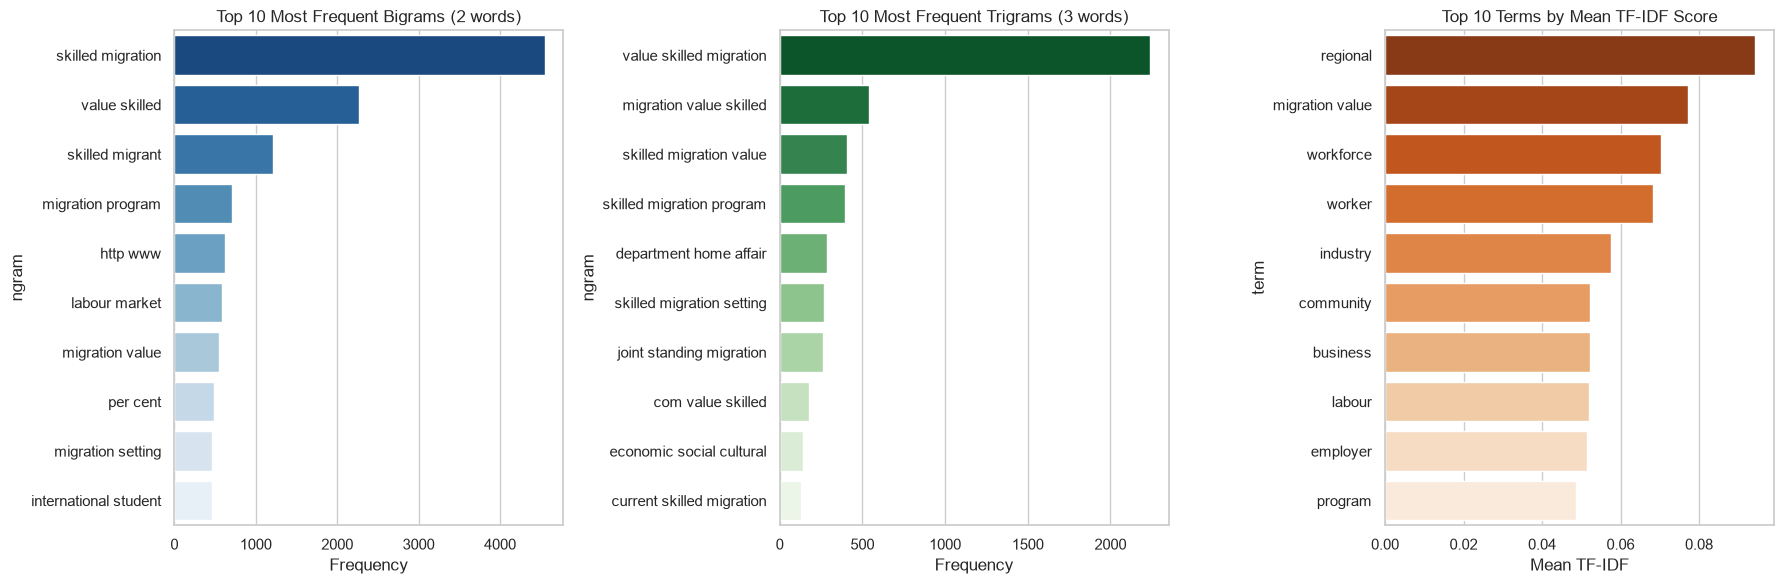


Final processed dataset saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_processed.csv


In [13]:
# --- 1. EXTRACT TOP N-GRAMS (BIGRAMS & TRIGRAMS) ---
print("Extracting top Bigrams and Trigrams...")

# Bigrams (2-word combinations)
count_bigrams = CountVectorizer(ngram_range=(2, 2), max_features=15)
bigram_matrix = count_bigrams.fit_transform(df['texto_limpio'])
bigram_counts = pd.DataFrame({
    'ngram': count_bigrams.get_feature_names_out(),
    'frequency': bigram_matrix.sum(axis=0).A1
}).sort_values(by='frequency', ascending=False)

# Trigrams (3-word combinations)
count_trigrams = CountVectorizer(ngram_range=(3, 3), max_features=15)
trigram_matrix = count_trigrams.fit_transform(df['texto_limpio'])
trigram_counts = pd.DataFrame({
    'ngram': count_trigrams.get_feature_names_out(),
    'frequency': trigram_matrix.sum(axis=0).A1
}).sort_values(by='frequency', ascending=False)


# --- 2. GENERATE FULL TF-IDF MATRIX ---
print("Generating TF-IDF Matrix...")

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.85,      # Ignore terms appearing in more than 85% of documents
    min_df=3,         # Ignore terms appearing in fewer than 3 documents
    ngram_range=(1, 2), # Include both single words and bigrams
    max_features=1000 # Limit vocabulary to top 1000 features
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['texto_limpio'])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"\n=== TF-IDF MATRIX SUMMARY ===")
print(f"Matrix Shape: {tfidf_matrix.shape}")
print(f"Documents (Rows): {tfidf_matrix.shape[0]}")
print(f"Vocabulary Features (Columns): {tfidf_matrix.shape[1]}")


# --- 3. TOP TF-IDF TERMS OVERALL ---
# Calculate average TF-IDF score per term across all documents
mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()
df_tfidf_top = pd.DataFrame({
    'term': tfidf_feature_names,
    'mean_tfidf': mean_tfidf
}).sort_values(by='mean_tfidf', ascending=False).head(15)

print("\n=== TOP 15 TERMS BY HIGHEST MEAN TF-IDF SCORE ===")
print(df_tfidf_top.to_string(index=False))


# --- 4. VISUALIZATION OF N-GRAMS AND TF-IDF ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Top Bigrams
sns.barplot(data=bigram_counts.head(10), x='frequency', y='ngram', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Most Frequent Bigrams (2 words)')
axes[0].set_xlabel('Frequency')

# Plot Top Trigrams
sns.barplot(data=trigram_counts.head(10), x='frequency', y='ngram', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Most Frequent Trigrams (3 words)')
axes[1].set_xlabel('Frequency')

# Plot Top TF-IDF Terms
sns.barplot(data=df_tfidf_top.head(10), x='mean_tfidf', y='term', ax=axes[2], palette='Oranges_r')
axes[2].set_title('Top 10 Terms by Mean TF-IDF Score')
axes[2].set_xlabel('Mean TF-IDF')

plt.tight_layout()
plt.show()


# --- 5. SAVE PROCESSED DATASET ---
PROCESSED_DATA_PATH = Path("/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed")
processed_csv_path = PROCESSED_DATA_PATH / "submissions_processed.csv"
df.to_csv(processed_csv_path, index=False)
print(f"\nFinal processed dataset saved successfully at:\n{processed_csv_path}")

### 2. [Topic Modeling/ Clustering/ RegEx....]

[Create separate sections for each approach and number them accordingly. Follow the same template as above - description of method, well documented code block, results and charts, explanation of results in your own words]


What differences do you see in the methods you tried and their results? What are the advantages, and limitations of each approach?

Evaluating optimal number of clusters (K)...


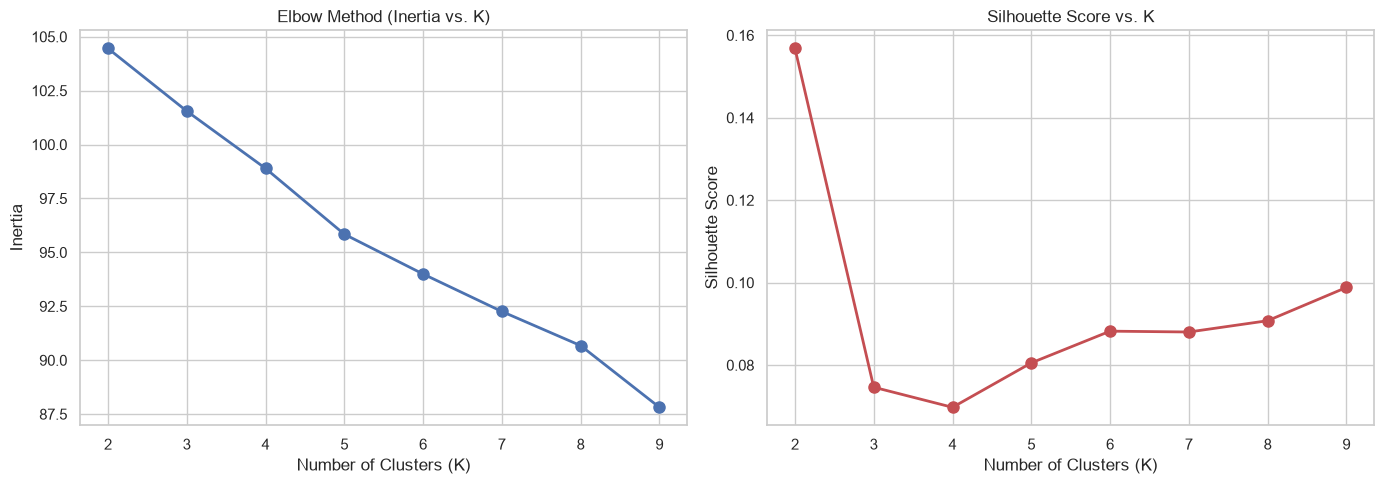


Optimal number of clusters suggested by Silhouette Score: K = 2

Training K-Means model with K = 2...
Document distribution per cluster:
cluster_kmeans
0    135
1      8
Name: count, dtype: int64

Reducing dimensions with PCA for 2D visualization...


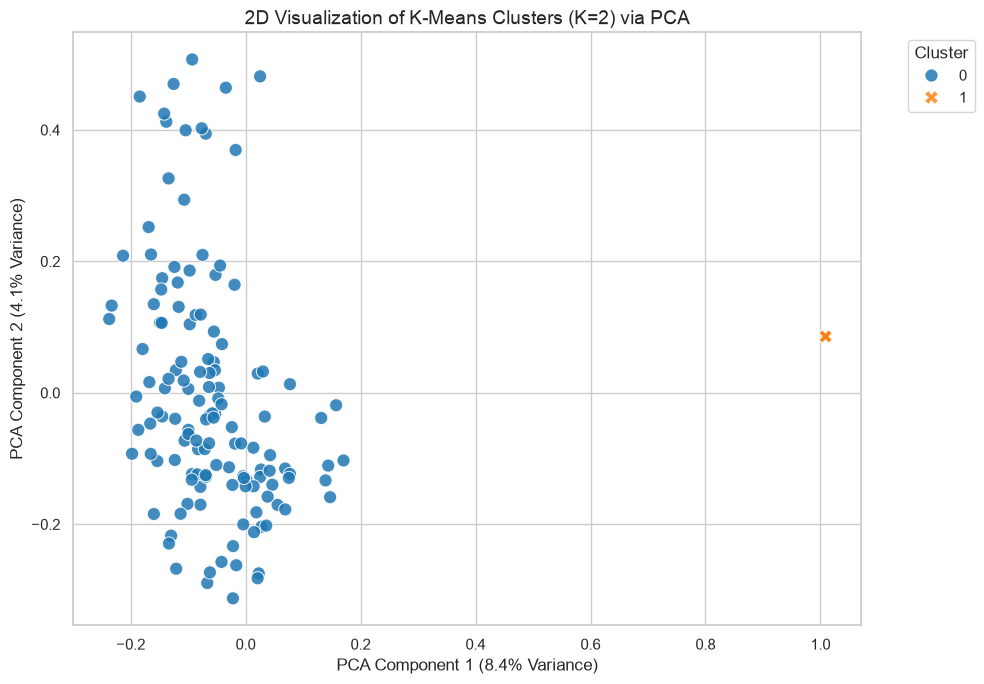

=== TOP 8 REPRESENTATIVE TERMS PER CLUSTER (K=2) ===

Cluster 0 (135 documents):
regional, workforce, worker, industry, community, business, labour, employer

Cluster 1 (8 documents):
migration value, zealand, figure, flexibility, five, fiscal, first, firm


In [ ]:


# --- 1. FIND OPTIMAL K (ELBOW METHOD & SILHOUETTE SCORE) ---
print("Evaluating optimal number of clusters (K)...")

k_range = range(2, 10)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertias.append(kmeans.inertia_)
    
    score = silhouette_score(tfidf_matrix, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow and Silhouette evaluation
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method Curve
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia vs. K)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

# Silhouette Score Curve
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs. K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Automatically select K with maximum Silhouette Score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters suggested by Silhouette Score: K = {optimal_k}")


# --- 2. TRAIN K-MEANS WITH OPTIMAL K ---
print(f"\nTraining K-Means model with K = {optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans_final.fit_predict(tfidf_matrix)

print("Document distribution per cluster:")
print(df['cluster_kmeans'].value_counts().sort_index())


# --- 3. DIMENSIONALITY REDUCTION & 2D VISUALIZATION (PCA) ---
print("\nReducing dimensions with PCA for 2D visualization...")
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(tfidf_matrix.toarray())

df['pca_x'] = pca_coords[:, 0]
df['pca_y'] = pca_coords[:, 1]

# Plot 2D Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, 
    x='pca_x', 
    y='pca_y', 
    hue='cluster_kmeans', 
    palette='tab10', 
    style='cluster_kmeans', 
    s=90, 
    alpha=0.85
)
plt.title(f'2D Visualization of K-Means Clusters (K={optimal_k}) via PCA', fontsize=14)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- 4. EXTRACT TOP TERMS PER CLUSTER ---
print(f"=== TOP 8 REPRESENTATIVE TERMS PER CLUSTER (K={optimal_k}) ===")
order_centroids = kmeans_final.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k):
    print(f"\nCluster {i} ({sum(df['cluster_kmeans'] == i)} documents):")
    top_terms = [tfidf_feature_names[ind] for ind in order_centroids[i, :8]]
    print(", ".join(top_terms))

Training K-Means with K = 4 for better thematic breakdown...

Document distribution per cluster:
cluster_kmeans
0     16
1    104
2      8
3     15
Name: count, dtype: int64


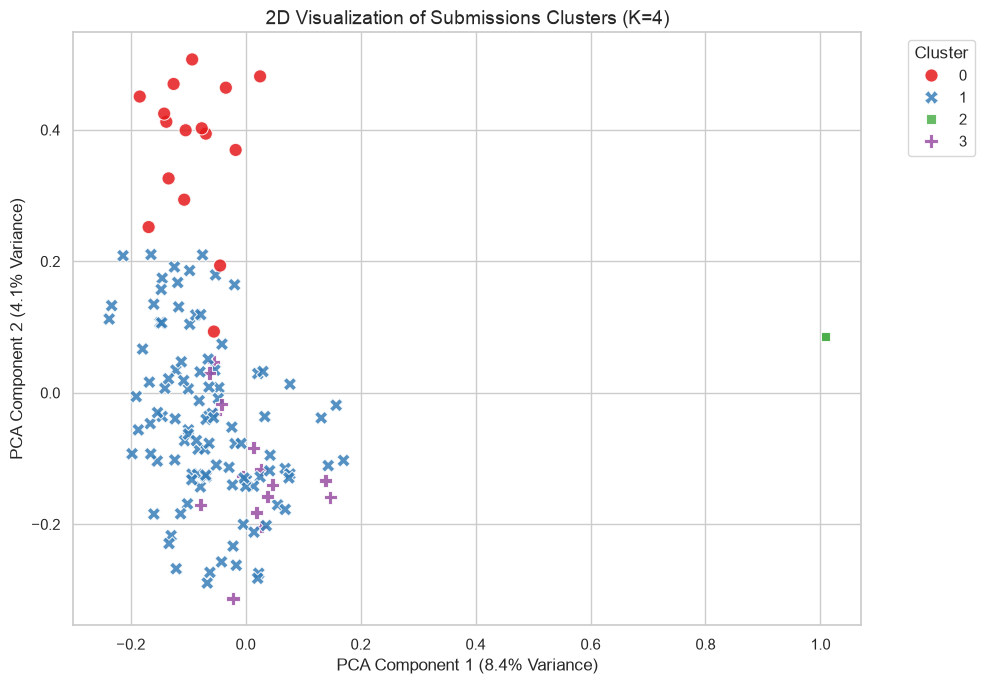

=== TOP 10 REPRESENTATIVE TERMS PER CLUSTER (K=4) ===

Cluster 0 (16 submissions):
 -> regional, community, local, rda, region, service, dama, workforce, local government, government

Cluster 1 (104 submissions):
 -> industry, worker, workforce, regional, labour, business, employer, program, student, system

Cluster 2 (8 submissions):
 -> migration value, zealand, figure, flexibility, five, fiscal, first, firm, finding, find

Cluster 3 (15 submissions):
 -> care, nurse, aged care, aged, nursing, aasw, worker, workforce, social work, health


In [15]:
# --- 1. FORCE A BALANCED AND INTERPRETABLE K (K=4) ---
k_balanced = 4
print(f"Training K-Means with K = {k_balanced} for better thematic breakdown...")

kmeans_balanced = KMeans(n_clusters=k_balanced, random_state=42, n_init=20)
df['cluster_kmeans'] = kmeans_balanced.fit_predict(tfidf_matrix)

print("\nDocument distribution per cluster:")
print(df['cluster_kmeans'].value_counts().sort_index())


# --- 2. 2D VISUALIZATION WITH PCA ---
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(tfidf_matrix.toarray())

df['pca_x'] = pca_coords[:, 0]
df['pca_y'] = pca_coords[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, 
    x='pca_x', 
    y='pca_y', 
    hue='cluster_kmeans', 
    palette='Set1', 
    style='cluster_kmeans', 
    s=90, 
    alpha=0.85
)
plt.title(f'2D Visualization of Submissions Clusters (K={k_balanced})', fontsize=14)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# --- 3. EXTRACT TOP REPRESENTATIVE TERMS PER CLUSTER ---
print(f"=== TOP 10 REPRESENTATIVE TERMS PER CLUSTER (K={k_balanced}) ===")
order_centroids = kmeans_balanced.cluster_centers_.argsort()[:, ::-1]

for i in range(k_balanced):
    doc_count = sum(df['cluster_kmeans'] == i)
    top_terms = [tfidf_feature_names[ind] for ind in order_centroids[i, :10]]
    print(f"\nCluster {i} ({doc_count} submissions):")
    print(" -> " + ", ".join(top_terms))

Preparing dictionary and corpus for LDA...
Dictionary Size (Unique Tokens): 5111
Total Processed Documents: 143

Evaluating LDA Topic Coherence Scores (Cv)...
Topics: 3 -> Coherence Score (Cv): 0.2946
Topics: 4 -> Coherence Score (Cv): 0.3398
Topics: 5 -> Coherence Score (Cv): 0.3526
Topics: 6 -> Coherence Score (Cv): 0.3556
Topics: 7 -> Coherence Score (Cv): 0.3397
Topics: 8 -> Coherence Score (Cv): 0.3485


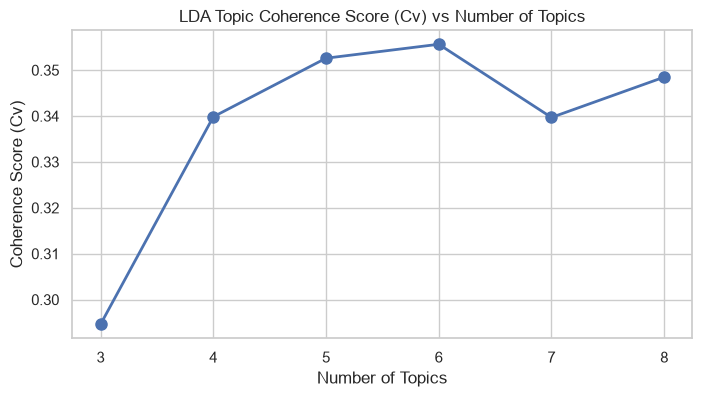


Optimal number of topics selected: 6 (Cv = 0.3556)

=== TOP 10 KEYWORDS PER TOPIC (LDA - 6 TOPICS) ===

Topic 1:
 -> workforce, care, international, social, worker, nurse, health, aged, assessment, education

Topic 2:
 -> regional, community, workforce, local, business, service, industry, economic, role, area

Topic 3:
 -> system, labour, economic, http, productivity, workforce, recognition, permanent, government, worker

Topic 4:
 -> worker, employer, program, palm, labour, occupation, scheme, subclass, regional, www

Topic 5:
 -> employer, occupation, industry, worker, training, trade, business, per, year, construction

Topic 6:
 -> program, south, refugee, state, regional, training, outcome, international, government, workforce

Generating interactive pyLDAvis visualization...
Interactive LDA visualization saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/lda_visualization.html


In [21]:


# --- 1. PREPARE DICTIONARY AND CORPUS FOR GENSIM ---
print("Preparing dictionary and corpus for LDA...")
tokens_list = [doc.split() for doc in df['texto_limpio'].dropna()]

# Create Dictionary
dictionary = corpora.Dictionary(tokens_list)

# Filter extreme words (appearing in < 3 docs or > 85% of docs)
dictionary.filter_extremes(no_below=3, no_above=0.85)

# Create Document-Term Matrix (Bag of Words)
corpus = [dictionary.doc2bow(tokens) for tokens in tokens_list]

print(f"Dictionary Size (Unique Tokens): {len(dictionary)}")
print(f"Total Processed Documents: {len(corpus)}")


# --- 2. EVALUATE TOPIC COHERENCE (FIND OPTIMAL NUMBER OF TOPICS) ---
print("\nEvaluating LDA Topic Coherence Scores (Cv)...")
topic_range = range(3, 9)
coherence_scores = []
lda_models = {}

for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=15,
        alpha='auto',
        eta='auto'
    )
    
    coherence_model = CoherenceModel(
        model=lda_model, 
        texts=tokens_list, 
        dictionary=dictionary, 
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    lda_models[num_topics] = lda_model
    print(f"Topics: {num_topics} -> Coherence Score (Cv): {score:.4f}")

# Plot Coherence Score curve
plt.figure(figsize=(8, 4))
plt.plot(topic_range, coherence_scores, 'bo-', linewidth=2, markersize=8)
plt.title('LDA Topic Coherence Score (Cv) vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (Cv)')
plt.grid(True)
plt.show()

# Select optimal model based on highest coherence
optimal_num_topics = topic_range[np.argmax(coherence_scores)]
best_lda_model = lda_models[optimal_num_topics]

print(f"\nOptimal number of topics selected: {optimal_num_topics} (Cv = {max(coherence_scores):.4f})")


# --- 3. PRINT TOP WORDS PER TOPIC ---
print(f"\n=== TOP 10 KEYWORDS PER TOPIC (LDA - {optimal_num_topics} TOPICS) ===")
for topic_id in range(optimal_num_topics):
    terms = best_lda_model.show_topic(topic_id, topn=10)
    words = [word for word, weight in terms]
    print(f"\nTopic {topic_id + 1}:")
    print(" -> " + ", ".join(words))




## --- 4. INTERACTIVE VISUALIZATION (pyLDAvis FIX FOR CIRCLE VISIBILITY) ---
print("\nGenerating interactive pyLDAvis visualization...")

# Prepare LDA visualization data
vis_data = gensimvis.prepare(best_lda_model, corpus, dictionary, sort_topics=False)

# Custom encoder function to convert non-serializable complex/numpy values
def clean_for_json(obj):
    if isinstance(obj, (np.complex128, np.complex64, complex)):
        return float(obj.real)
    if isinstance(obj, (np.float64, np.float32, np.float16)):
        return float(obj)
    if isinstance(obj, (np.int64, np.int32, np.int16, np.int8)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [clean_for_json(x) for x in obj]
    if isinstance(obj, pd.DataFrame):
        return obj.map(clean_for_json)
    if isinstance(obj, pd.Series):
        return obj.map(clean_for_json)
    return obj

# Clean internal data structures
cleaned_topic_coordinates = clean_for_json(vis_data.topic_coordinates)
cleaned_topic_info = clean_for_json(vis_data.topic_info)
cleaned_token_table = clean_for_json(vis_data.token_table)

cleaned_vis_data = pyLDAvis.PreparedData(
    topic_coordinates=cleaned_topic_coordinates,
    topic_info=cleaned_topic_info,
    token_table=cleaned_token_table,
    R=vis_data.R,
    lambda_step=vis_data.lambda_step,
    plot_opts=vis_data.plot_opts,
    topic_order=vis_data.topic_order
)

# Convert to raw HTML string
html_string = pyLDAvis.prepared_data_to_html(cleaned_vis_data)

# Inject custom CSS to force SVG circles to be visible permanently
css_override = """
<style>
    circle.bubble {
        fill-opacity: 0.6 !important;
        stroke: #333 !important;
        stroke-width: 1px !important;
    }
    circle.bubble:hover {
        fill-opacity: 0.9 !important;
        stroke-width: 2px !important;
    }
</style>
"""
html_string_fixed = css_override + html_string

# Save as standalone HTML
html_output_path = PROCESSED_DATA_PATH / "lda_visualization.html"
with open(html_output_path, 'w', encoding='utf-8') as f:
    f.write(html_string_fixed)

print(f"Interactive LDA visualization saved successfully at:\n{html_output_path}")

# Render in Notebook output
display(HTML(html_string_fixed))

/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/.venv/lib/python3.12/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'ver

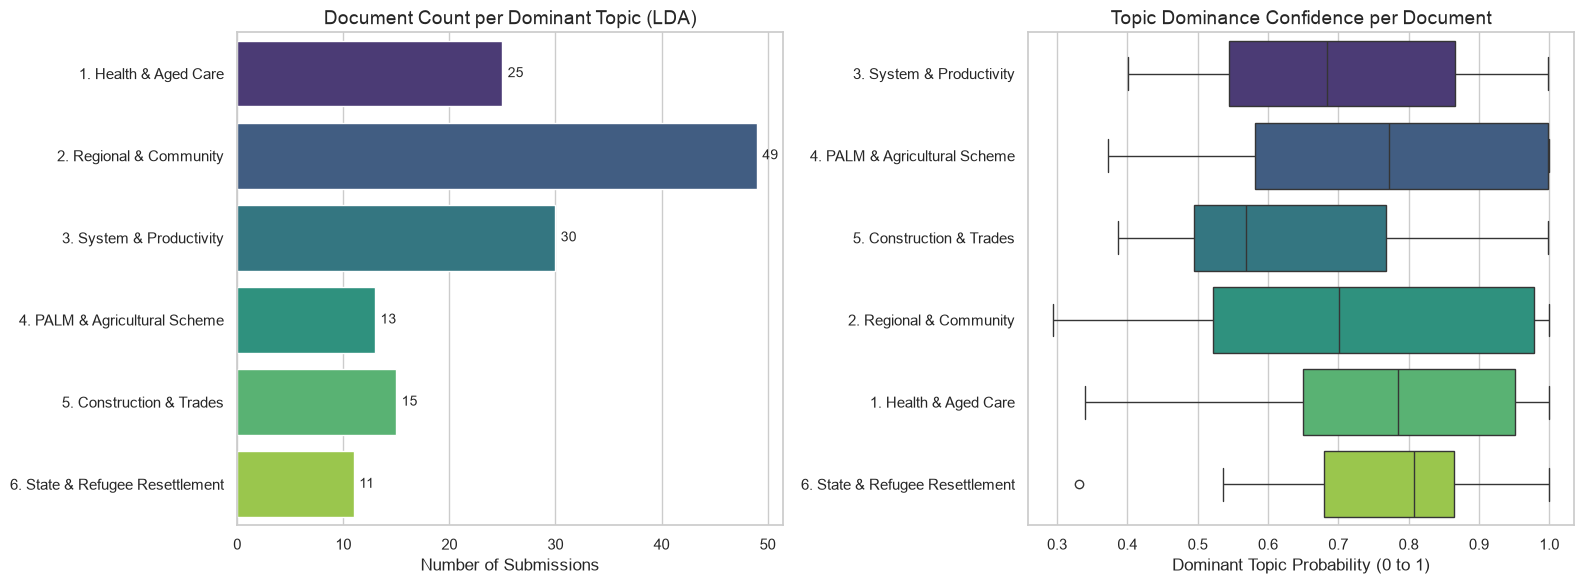


=== FINAL SUMMARY ===
Total Submissions Analyzed: 143
Final dataset saved successfully at:
/Users/diegoz/Documents/portfolio_data_science/aplied_natural_language_processing_anlp/text_analysis/data/processed/submissions_final_analysis.csv


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. ASSIGN DOMINANT TOPIC TO EACH DOCUMENT ---
def get_dominant_topic_data(lda_model, corpus):
    dominant_topics = []
    topic_probs = []
    for doc_bow in corpus:
        topics = lda_model.get_document_topics(doc_bow)
        topics.sort(key=lambda x: x[1], reverse=True)
        dominant_topics.append(topics[0][0] + 1) # Topic ID 1 to 6
        topic_probs.append(topics[0][1])          # Contribution percentage
    return dominant_topics, topic_probs

df['lda_dominant_topic'], df['lda_topic_probability'] = get_dominant_topic_data(best_lda_model, corpus)

# Mapping names for readable plots
topic_names = {
    1: "1. Health & Aged Care",
    2: "2. Regional & Community",
    3: "3. System & Productivity",
    4: "4. PALM & Agricultural Scheme",
    5: "5. Construction & Trades",
    6: "6. State & Refugee Resettlement"
}
df['lda_topic_name'] = df['lda_dominant_topic'].map(topic_names)


# --- 2. STATIC PLOTS: TOPIC DISTRIBUTION & KEYWORDS MAP ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Document Count per Topic
topic_counts = df['lda_topic_name'].value_counts().reset_index()
topic_counts.columns = ['Topic', 'Count']
topic_counts = topic_counts.sort_values(by='Topic')

sns.barplot(
    data=topic_counts, 
    x='Count', 
    y='Topic', 
    hue='Topic', 
    ax=axes[0], 
    palette='viridis', 
    legend=False
)
axes[0].set_title('Document Count per Dominant Topic (LDA)', fontsize=14)
axes[0].set_xlabel('Number of Submissions')
axes[0].set_ylabel('')

# Add value labels to bars
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f'{int(width)}', (width + 0.5, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', fontsize=10)

# Plot 2: Topic Probabilities Distribution
sns.boxplot(
    data=df, 
    x='lda_topic_probability', 
    y='lda_topic_name', 
    hue='lda_topic_name', 
    ax=axes[1], 
    palette='viridis', 
    legend=False
)
axes[1].set_title('Topic Dominance Confidence per Document', fontsize=14)
axes[1].set_xlabel('Dominant Topic Probability (0 to 1)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


# --- 3. SAVE FINAL DATASET ---
final_csv_path = PROCESSED_DATA_PATH / "submissions_final_analysis.csv"
df.to_csv(final_csv_path, index=False)

print(f"\n=== FINAL SUMMARY ===")
print(f"Total Submissions Analyzed: {len(df)}")
print(f"Final dataset saved successfully at:\n{final_csv_path}")

### Conclusion

[Summary of findings from the data and any future recommended steps]

Your interpretive summary on the question provided (refer detailed assessment brief)

### References

[Add full list of references]